# Mixing transects in ACCESS-OM3

Transects of vertical mixing near WOCE/GO-SHIP hydrographic lines, to investigate deep thermocline bias - see
- https://github.com/ACCESS-NRI/access-om3-configs/issues/1525
- https://github.com/ACCESS-Community-Hub/access-om3-paper-1/issues/13#issuecomment-5111610363

Based on `Transects.ipynb`

In [1]:
# These first two cells must be in all notebooks!
# It allows us to run all the notebooks at once, this cell has a tag "parameters" which allows us to pass in 
# arguments externally using papermill (see mkfigs.sh for details)

# Set esm_file to the datastore for the main experiment of interest
# esm_file = "/g/data/ol01/outputs/access-om3-25km/25km-iaf-test-for-AK-expt-7df5ef4c/datastore.json"
# esm_file = "/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf-1.0-beta-5165c0f8/datastore.json"
# esm_file = "/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test3v2-00532b88/datastore.json"
# esm_file = "/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test4-d28e0359/datastore.json"
esm_file = "/scratch/tm70/aek156/access-om3/archive/MC_25km_jra_iaf+wombatlite-test4-rerun-099ed2b5/datastore.json"
# esm_file = "/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-03-06-2026/cm3-datastore/cm3-datastore.json"

# papermill settings. *No need to modify these if running interactively.* 
papermill = False                      # `cwd` and `nbname` will be populated by papermill.
cwd = None                             # current working directory 
nbname = None                          # notebook name

In [2]:
import os
if not papermill: 
    import nci_ipynb  # requires conda/analysis3-26.03 or later
    cwd = nci_ipynb.dir()
    nbname = nci_ipynb.name()
    os.chdir(cwd)
import mkfigs_bootstrap  # noqa: adds external/access-model-mkfigs/src to sys.path (stop-gap)
from mkfigs import MkmdWriter
mkmd = MkmdWriter(esm_file, nbname, str(cwd), pm=papermill)
from exptdata_access import guess_experiment_from_esm_file
expt_key, info = guess_experiment_from_esm_file(esm_file)
model_name = info["model"]  # OM3 or CM3

In [3]:
import intake
from dask.distributed import Client
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.ticker as mticker
import cmocean
import cartopy.crs as ccrs
import cftime
import cf_xarray as cfxr
import cf_xarray.units
import numpy as np
import xarray as xr
import xgcm
from textwrap import wrap

In [4]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [5]:
from model_agnostic import patch_broken_conda_env, patch_dask_workers
patch_broken_conda_env()   # no-op on healthy conda envs
client = Client(threads_per_worker=1)
patch_dask_workers(client)  # patch workers too
print(client.dashboard_link)
client

/proxy/8787/status


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 125.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41197,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39197,Total threads: 1
Dashboard: /proxy/45321/status,Memory: 4.47 GiB
Nanny: tcp://127.0.0.1:44553,


In [6]:
IAF = esm_file.find('iaf') > 0
IAF

True

## Load ACCESS-OM3 data from ESM datastore

In [7]:
if model_name == "ACCESS-CM3":
    catalogs = [esm_file]
else:
    catalogs = [
                # '/g/data/ol01/access-om3-output/access-om3-025/MC_25km_jra_ryf-1.0-beta/experiment_datastore.json',
                # '/g/data/ol01/access-om3-output/access-om3-025/25km-iaf-test-for-AK-expt-7df5ef4c/datastore.json',
                # '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf-1.0-beta-5165c0f8/datastore.json',
                esm_file,
                # '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test3v2-COARE-12fab415/datastore.json',
            ]
catalogs

['/scratch/tm70/aek156/access-om3/archive/MC_25km_jra_iaf+wombatlite-test4-rerun-099ed2b5/datastore.json']

In [8]:
om3datastores = { os.path.normpath(c).split(os.sep)[-2]:
               intake.open_esm_datastore(c,
                                         columns_with_iterables=[
                                            "variable",
                                            "variable_long_name",
                                            "variable_standard_name",
                                            "variable_cell_methods",
                                            "variable_units"]
                                        )
              for c in catalogs }
om3datastores

{'MC_25km_jra_iaf+wombatlite-test4-rerun-099ed2b5': <datastore catalog with 24 dataset(s) from 3799 asset(s)>}

In [9]:
om3exptname = os.path.basename(os.path.dirname(esm_file))
om3exptname

'MC_25km_jra_iaf+wombatlite-test4-rerun-099ed2b5'

## Load data from ACCESS-OM3

In [10]:
om3varnames = [ # variables on z-level cell centres
                'thetao', # potential temperature
                'Kd_Itidal_Work',
              ]

om3chunks = {"time": -1}
if model_name == "ACCESS-CM3":
    om3chunks = {"time": 1}  # CM3 stores yearly files

om3data = {
            expt: ds.search(variable=om3varnames,
                            filename=".*mean.*",
                            # variable_cell_methods='.*time: max.*'
                            ).to_dask(
                xarray_open_kwargs = dict(
                    chunks=om3chunks,
                    decode_timedelta=True
                )
            )
            for expt, ds in om3datastores.items()
          }

if IAF or model_name == "ACCESS-CM3":  # common calendar for obs overlays
    for expt, ds in om3data.items():
        try:
            om3data[expt] = ds.convert_calendar("proleptic_gregorian", use_cftime=True)
        except KeyError:
            pass

om3mask = np.isfinite(om3data[om3exptname][om3varnames[0]].isel(time=0)).load()

In [11]:
om3data[om3exptname]

<xarray.Dataset> Size: 96GB
Dimensions:         (time: 96, z_l: 75, yh: 1152, xh: 1440)
Coordinates:
  * time            (time) object 768B 1958-01-16 12:00:00 ... 1965-12-16 12:...
  * z_l             (z_l) float64 600B 0.5413 1.681 2.94 ... 5.511e+03 5.709e+03
  * yh              (yh) float64 9kB -81.58 -81.52 -81.45 ... 89.74 89.84 89.95
  * xh              (xh) float64 12kB -279.9 -279.6 -279.4 ... 79.38 79.62 79.88
Data variables:
    Kd_Itidal_Work  (time, z_l, yh, xh) float32 48GB dask.array<chunksize=(12, 75, 192, 160), meta=np.ndarray>
    thetao          (time, z_l, yh, xh) float32 48GB dask.array<chunksize=(12, 75, 192, 160), meta=np.ndarray>
Attributes:
    title:                            ACCESS-OM3
    associated_files:                 areacello: access-om3.mom6.static.nc
    grid_type:                        regular
    grid_tile:                        N/A
    intake_esm_attrs:file_id:         ocean.1mon.nv:2.xh:1440.yh:1152.z_i:76....
    intake_esm_attrs:frequency:       1mon
    intake_esm_attrs:realm:           ocean
    intake_esm_attrs:temporal_label:  mean
    intake_esm_attrs:_data_format_:   netcdf
    intake_esm_dataset_key:           ocean.1mon.nv:2.xh:1440.yh:1152.z_i:76....

In [12]:
om3varnames_2d = [ # 2d variables
                'ePBL_h_ML',
                'h_ML',
              ]

om3chunks = {"time": -1}
if model_name == "ACCESS-CM3":
    om3chunks = {"time": 1}  # CM3 stores yearly files

om3data_2d = {
            expt: ds.search(variable=om3varnames_2d,
                            # filename=".*mean.*", # doesn't work
                            # variable_cell_methods='.*time: mean.*' # doesn't work
                            ).to_dask(
                xarray_open_kwargs = dict(
                    chunks=om3chunks,
                    decode_timedelta=True
                )
            )
            for expt, ds in om3datastores.items()
          }

if IAF or model_name == "ACCESS-CM3":  # common calendar for obs overlays
    for expt, ds in om3data_2d.items():
        try:
            om3data_2d[expt] = ds.convert_calendar("proleptic_gregorian", use_cftime=True)
        except KeyError:
            pass

In [13]:
om3data_2d[om3exptname]

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 96, yh: 1152, xh: 1440)
Coordinates:
  * time       (time) object 768B 1958-01-16 12:00:00 ... 1965-12-16 12:00:00
  * yh         (yh) float64 9kB -81.58 -81.52 -81.45 ... 89.74 89.84 89.95
  * xh         (xh) float64 12kB -279.9 -279.6 -279.4 ... 79.38 79.62 79.88
Data variables:
    ePBL_h_ML  (time, yh, xh) float32 637MB dask.array<chunksize=(12, 192, 160), meta=np.ndarray>
    h_ML       (time, yh, xh) float32 637MB dask.array<chunksize=(12, 192, 160), meta=np.ndarray>
Attributes: (12/13)
    title:                                    ACCESS-OM3
    associated_files:                         areacello: access-om3.mom6.stat...
    grid_type:                                regular
    grid_tile:                                N/A
    intake_esm_attrs:file_id:                 ocean.1mon.nv:2.xh:1440.yh:1152
    intake_esm_attrs:frequency:               1mon
    ...                                       ...
    intake_esm_attrs:variable_cell_methods:   ,,,area:mean yh:mean xh:mean ti...
    intake_esm_attrs:variable_units:          days,days since 1900-01-01 00:0...
    intake_esm_attrs:realm:                   ocean
    intake_esm_attrs:temporal_label:          mean
    intake_esm_attrs:_data_format_:           netcdf
    intake_esm_dataset_key:                   ocean.1mon.nv:2.xh:1440.yh:1152...

In [14]:
om3varnames_i = [ # variables on interfaces
                # 'difvho', # Kd_heat: Total diapycnal diffusivity for heat at interfaces
                # 'difvso', # Kd_salt: Total diapycnal diffusivity for salt at interfaces
                'Kd_interface', # Total diapycnal diffusivity at interfaces (min of Kd_heat, Kd_salt - see https://github.com/ACCESS-NRI/access-om3-configs/issues/1046#issuecomment-5312597952 )
                'Kd_ePBL', # ePBL diapycnal diffusivity at interfaces
                'Kd_shear', # Shear-driven Diapycnal Diffusivity at horizontal tracer points
                'Kd_bkgnd', # Background diffusivity added by MOM_bkgnd_mixing module
                'Kd_itides', # Internal Tide Driven Diffusivity
                'Kd_BBL', # Bottom Boundary Layer Diffusivity
                # #     # 'rsdoabsorb'
              ]

om3chunks = {"time": -1}
if model_name == "ACCESS-CM3":
    om3chunks = {"time": 1}  # CM3 stores yearly files

om3data_i = {
            expt: ds.search(variable=om3varnames_i).to_dask(
                xarray_open_kwargs = dict(
                    chunks=om3chunks,
                    decode_timedelta=True
                )
            )
            for expt, ds in om3datastores.items()
          }
    
if IAF or model_name == "ACCESS-CM3":  # common calendar for obs overlays
    for expt, ds in om3data_i.items():
        try:
            om3data_i[expt] = ds.convert_calendar("proleptic_gregorian", use_cftime=True)
        except KeyError:
            pass

In [15]:
om3data_i[om3exptname]

<xarray.Dataset> Size: 290GB
Dimensions:       (time: 96, zi: 76, yh: 1152, xh: 1440)
Coordinates:
  * time          (time) object 768B 1958-01-16 12:00:00 ... 1965-12-16 12:00:00
  * zi            (zi) float64 608B 0.0 1.083 2.279 ... 5.412e+03 5.61e+03 6e+03
  * yh            (yh) float64 9kB -81.58 -81.52 -81.45 ... 89.74 89.84 89.95
  * xh            (xh) float64 12kB -279.9 -279.6 -279.4 ... 79.38 79.62 79.88
Data variables:
    Kd_BBL        (time, zi, yh, xh) float32 48GB dask.array<chunksize=(12, 76, 192, 160), meta=np.ndarray>
    Kd_bkgnd      (time, zi, yh, xh) float32 48GB dask.array<chunksize=(12, 76, 192, 160), meta=np.ndarray>
    Kd_ePBL       (time, zi, yh, xh) float32 48GB dask.array<chunksize=(12, 76, 192, 160), meta=np.ndarray>
    Kd_interface  (time, zi, yh, xh) float32 48GB dask.array<chunksize=(12, 76, 192, 160), meta=np.ndarray>
    Kd_itides     (time, zi, yh, xh) float32 48GB dask.array<chunksize=(12, 76, 192, 160), meta=np.ndarray>
    Kd_shear      (time, zi, yh, xh) float32 48GB dask.array<chunksize=(12, 76, 192, 160), meta=np.ndarray>
Attributes:
    title:                                    ACCESS-OM3
    associated_files:                         areacello: access-om3.mom6.stat...
    grid_type:                                regular
    grid_tile:                                N/A
    intake_esm_attrs:file_id:                 ocean.1mon.nv:2.xh:1440.yh:1152...
    intake_esm_attrs:frequency:               1mon
    intake_esm_attrs:variable_standard_name:  ,,,,,,,,,
    intake_esm_attrs:variable_cell_methods:   area:mean zi:point yh:mean xh:m...
    intake_esm_attrs:realm:                   ocean
    intake_esm_attrs:temporal_label:          mean
    intake_esm_attrs:_data_format_:           netcdf
    intake_esm_dataset_key:                   ocean.1mon.nv:2.xh:1440.yh:1152...

#### Load OM3 grid data

In [16]:
# regex matches access-om3 and access-cm3 static files
static = xr.open_dataset(om3datastores[om3exptname].search(filename=".*mom6.static.nc").df.loc[0, "path"]).drop_vars("time")

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/argopy/utils/lists.py:38: UserWarning: An error occurred while loading the ERDDAP data fetcher, it will not be available !
<class 'ImportError'>
cannot import name '_quote_string_constraints' from 'erddapy.erddapy' (/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/erddapy/erddapy.py)
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/argopy/utils/lists.py:50: UserWarning: An error occurred while loading the ArgoVis data fetcher, it will not be available !
<class 'ImportError'>
cannot import name '_quote_string_constraints' from 'erddapy.erddapy' (/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/erddapy/erddapy.py)
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/argopy/utils/lists.py:66: UserWarning: An error occurred while loadi

In [17]:
# See https://xgcm.readthedocs.io/en/latest/xgcm-examples/03_MOM6/#xgcm-grid-definition
symmetric = True  # True for ACCESS-OM3 2025.08.000 and later

if symmetric:  # ACCESS-OM3 version 2025.08.000 and later: one more q point than h points
    coords={
        'X': {'center': 'xh', 'outer': 'xq'},
        'Y': {'center': 'yh', 'outer': 'yq'},
        # 'Z': { 'inner': 'z_l', 'outer': 'z_i'}
    }
else:  # ACCESS-OM3 versions prior to 2025.08.000: equal number of q and h points
    coords={
        'X': {'center': 'xh', 'right': 'xq'},
        'Y': {'center': 'yh', 'right': 'yq'},
        # 'Z': { 'inner': 'z_l', 'outer': 'z_i'}
    }

grid = xgcm.Grid(
    static,
    coords=coords,
    metrics = {
        ('X',): ['dxt', 'dxCu', 'dxCv'], # X distances
        ('Y',): ['dyt', 'dyCu', 'dyCv'], # Y distances
        ('X', 'Y'): ['areacello', 'areacello_cu', 'areacello_cv', 'areacello_bu'] # Areas
    },
    periodic=['X'],
    autoparse_metadata=False
# Note, autoparse_metadata=False is required below for xgcm >= 0.9.0 to prevent xgcm 
# from trying to autoparse non-existent grid information from the file metadata, 
# leading to the error:
# ValueError: Found two coordinates without `c_grid_axis_shift` attribute for axis X
)

## Load data from ACCESS-OM2
use control - see https://forum.access-hive.org.au/t/access-om2-control-experiments/258#p-747-ryf-7

In [18]:
if IAF:
    om2exptname = '025deg_jra55_iaf_omip2_cycle1'
else:
    om2exptname = '025deg_jra55_ryf9091_gadi'  # monthly temp only for 1900-1903, and 2300-, with annual data in the gap
om2datastores = {}#{om2exptname: intake.cat.access_nri[om2exptname]}

In [19]:
om2varnames = [  ] 

om2data = {
            expt: ds.search(variable=om2varnames, frequency="1mon").to_dask(
                xarray_open_kwargs = dict(
                    chunks={"xt_ocean": "auto", "yt_ocean": "auto", "st_ocean" : "auto"},
                    decode_timedelta=True
                )
            )
            for expt, ds in om2datastores.items()
          }

if IAF or model_name == "ACCESS-CM3":  # common calendar for obs overlays
    for expt, ds in om2data.items():
        try:
            om2data[expt] = ds.convert_calendar("proleptic_gregorian", use_cftime=True)
        except KeyError:
            pass

try:
    om2mask = np.isfinite(om2data[om2exptname][om2varnames[0]].isel(time=0)).load()
except KeyError:
    pass

## Set time range and calculate time average

In [20]:
firsttime = []
lasttime = []
for expt, ds in om3data_i.items():
    firsttime.append(ds.time.values[0])
    lasttime.append(ds.time.values[-1])
for expt, ds in om3data.items():
    firsttime.append(ds.time.values[0])
    lasttime.append(ds.time.values[-1])
for expt, ds in om2data.items():
    firsttime.append(ds.time.values[0])
    lasttime.append(ds.time.values[-1])

if IAF:
    # datestop = cftime.DatetimeProlepticGregorian(2018, 12, 31, 12, 0, 0, 0, has_year_zero=True)  # to match OM2 IAF run
    datestart = max(firsttime) # latest first date in data
    datestop = min(lasttime) # earliest final date in data
    datelist = list(cftime.to_tuple(datestop))
    # datelist[0] -= 2
    datelist[0] -= 25-1  # last 25 years
    datestart = max(datestart, cftime.datetime(*datelist, calendar=datestop.calendar))
    # bracket to start/end of year
    datestart = cftime.datetime(cftime.to_tuple(datestart)[0],  1, 1, calendar=datestop.calendar)
    datestop  = cftime.datetime(cftime.to_tuple(datestop)[0], 12, 31, 23, 59, 59, calendar=datestop.calendar)
    timerange = slice(datestart, datestop)
# manually set range instead of using the above
    # timerange = slice(cftime.DatetimeProlepticGregorian(1958, 1, 1, 0, 0, 0, 0),
    #                   cftime.DatetimeProlepticGregorian(1959, 1, 1, 0, 0, 0, 0))
    # timerange = slice(cftime.DatetimeProlepticGregorian(1962, 1, 1, 0, 0, 0, 0),
    #                   cftime.DatetimeProlepticGregorian(1963, 1, 1, 0, 0, 0, 0))
else:
    timerange = slice(cftime.DatetimeNoLeap(1932, 1, 1, 0, 0, 0, 0),
                      cftime.DatetimeNoLeap(1952, 1, 1, 0, 0, 0, 0))

# timerange = slice(None, None) # all times

timerange

slice(cftime.datetime(1958, 1, 1, 0, 0, 0, 0, calendar='proleptic_gregorian', has_year_zero=True), cftime.datetime(1965, 12, 31, 23, 59, 59, 0, calendar='proleptic_gregorian', has_year_zero=True), None)

In [21]:
%%time
for expt, ds in om3data.items():
    om3data[expt] = ds.sel(time=timerange).mean('time').load()
for expt, ds in om3data_2d.items():
    om3data_2d[expt] = ds.sel(time=timerange).mean('time').load()
for expt, ds in om3data_i.items():
    om3data_i[expt] = ds.sel(time=timerange).mean('time').load()
# for expt, ds in om2data.items():
#     om2data[expt] = ds.sel(time=timerange).mean('time').load()

CPU times: user 1min 12s, sys: 1min 1s, total: 2min 13s
Wall time: 2min 55s


In [22]:
# mask out vanished layers
for expt, ds in om3data_i.items():
    depth = om3datastores[expt].search(variable='deptho').to_dask()['deptho']
    om3data_i[expt] = ds.where(ds.zi < depth).load()

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/intake_esm/source.py:314: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only first dataset. Request valid dimension coordinate to silence this warning.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 2.82 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


## Load data from WOA

NB: we're taking a mean of the monthly means. This reduces seasonal bias relative to the annual mean WOA (I think!), but will also involve more interpolated values.

The alternative would be to use the WOA annual mean `/g/data/ik11/observations/woa23/woa23_decav_[ts]00_04.nc` but this needs to be converted to the appropriate temperature and salinity, and regridded to model grid.


In [23]:
obsdata = dict()

### WOA23 for comparison to OM3

In [24]:
# fragile! obs_file_pattern depends on model run!
# obs_file_pattern = "/g/data/ik11/inputs/access-om3/woa23/025/2025.10.24/woa23_ts_*"
# obs_file_pattern = "/g/data/ik11/inputs/access-om3/woa23/025/2026.06.11/woa23_ts_01_mom.nc"  # initial condiion for MC_25km_jra_iaf+wombatlite-test4-d28e0359
obs_file_pattern = "/g/data/ik11/inputs/access-om3/woa23/025/2026.06.11/woa23_ts_*"  # all months for MC_25km_jra_iaf+wombatlite-test4-d28e0359

obsdata['woa23'] = xr.open_mfdataset(
        obs_file_pattern,
        chunks={"time": -1})\
    .cf.mean("time")\
    .rename({'lon': 'xh', 'lat': 'yh', 'depth': 'z_l'})\
    .where(om3mask)  # mask out interpolated values at dry points in model

## Define transect locations
Compare to the [GO-SHIP transects](http://www.go-ship.org/RefSecs/go-ship_floating_status.png) - note that most of them are not purely zonal or meridional!

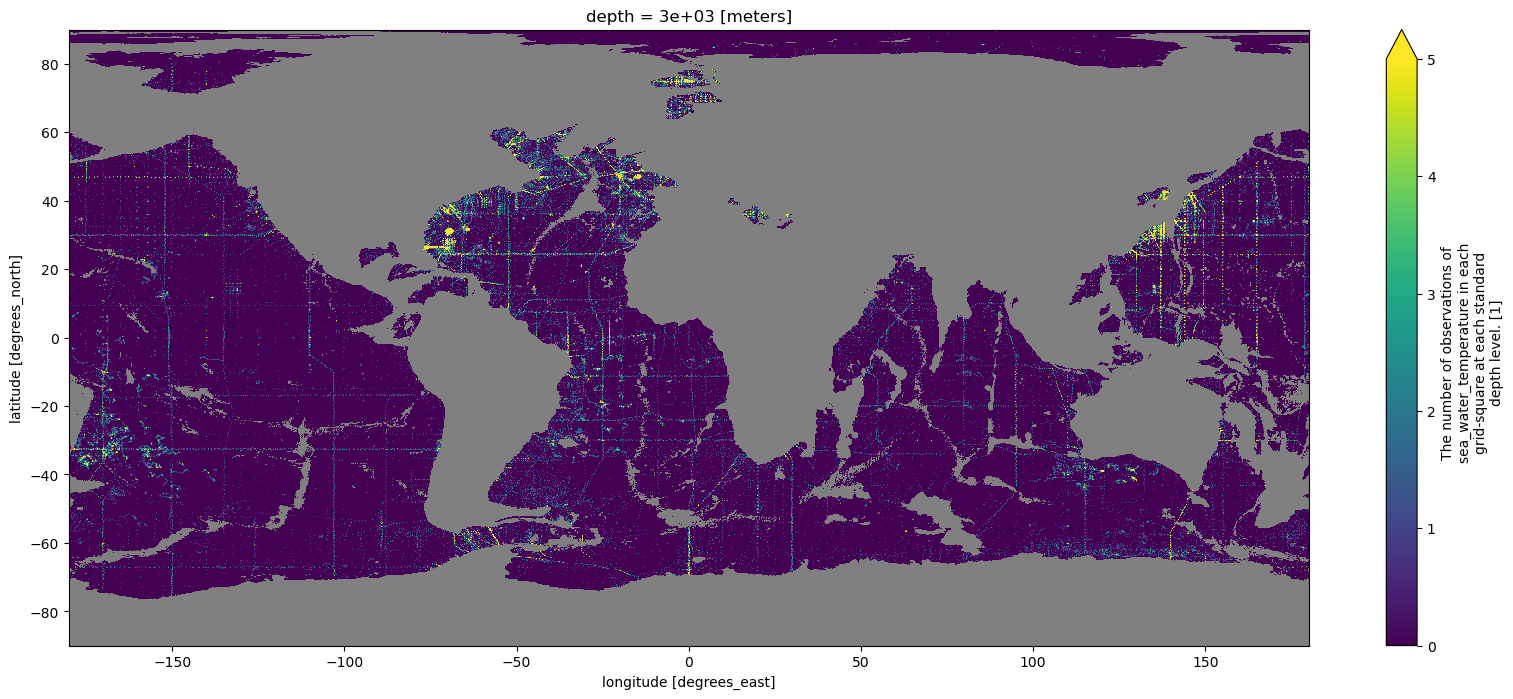

In [25]:
# Example: number of T obs underlying WAO23 at 3000m depth.
# Using seasonal decav data, which extends full depth.
# NB: use mean instead of sum so that land is nan, and then multiply by 4 to get sum.
woa23_obs = 4.0 * xr.open_mfdataset('/g/data/av17/access-nri/OM3/woa23/woa23_decav_t1[3-6]_04.nc',
                 decode_times=False).mean('time').sel(depth=3000, method='nearest').t_dd.load()

plt.figure(figsize=(20, 8))
woa23_obs.plot(vmax=5)
plt.gca().set_facecolor('gray')  # gray land points

{'P16': [-149.875, -149.875, -76, 61],
 'P02': [-237, -117, 30.02344512939453, 30.02344512939453]}

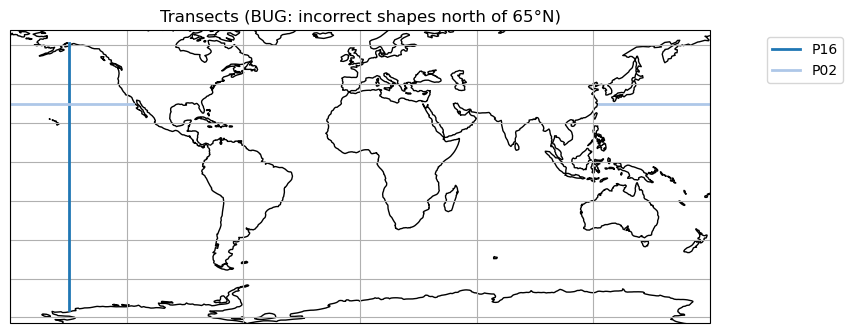

In [26]:
# Transects: [minlon, maxlon, minlat, maxlat]
# Add as many as you like, but they must be zonal or meridional
transects = {
    # 'SR3': [140-360, 140-360, -67, -42], # to match Kiss et al 2020
    'P16': [-150, -150, -76, 61], # to match Kiss et al 2020
    # 'A16': [-25, -25, -75.01, 65], # to match Kiss et al 2020
    # 'I08-09': [95-360, 95-360, -65, 15.1], # to match Kiss et al 2020
    'P02': [ -237, -117, 30, 30],
    # 'P04': [ -235, -85, 9.5, 9.5],
    # 'P06': [ -207, -72, -32.5, -32.5],
    # 'OSNAP': [-62, -5, 59, 59], # only roughly near OSNAP
    # 'A02': [-52, -5, 48, 48], # only roughly near A02
    # 'A05': [-96, -17, 24.5, 24.5],
    # 'A10': [-50, 17, -30, -30],
    # 'Mediterranean outflow': [-75, -6, 36, 36],
    # 'I05 west': [29, 80, -33, -33],
    # 'I05 east': [-280, -246, -33, -33],
}

for transect, (minlon, maxlon, minlat, maxlat) in transects.items():
    if (minlon != maxlon) and (minlat != maxlat):
        raise ValueError(f'Error in {model} {transect}: Must have either minlon == maxlon or minlat == maxlat')

transects = {k: dict(zip(["minx", "maxx", "miny", "maxy"], v)) for k, v in transects.items()}  # convert to dicts

for r, d in transects.items():
    for k, x in d.items():
        if k in ["minx", "maxx"] and x != max(-280, min(x, 80)):
            raise ValueError(f"{r} {k} = {x} is outside the range -280 to 80")
        if k in ["miny", "maxy"] and x > 65:
            print(f"{r} {k} changed from {x} to 65 to omit tripolar region")
            d[k] = 65
 
# Quantise OM3 transect locations to relevant grid
for transect, d in transects.items():
    if d['minx'] == d['maxx']:
        d['minx'] = d['maxx'] = om3data_i[om3exptname].sel(xh=d['minx'], method='nearest').xh.values.tolist()
    elif d['miny'] == d['maxy']:
        d['miny'] = d['maxy'] = om3data_i[om3exptname].sel(yh=d['miny'], method='nearest').yh.values.tolist()


# revert to array for coords
transects = {k: list(d.values()) for k, d in transects.items()}

fig = plt.figure(figsize=(10, 4))

colors = mpl.color_sequences['tab20']

ax = plt.axes(position=[0.05,0.05,0.7,0.9], projection=ccrs.PlateCarree())
ax.coastlines(resolution="110m")
ax.gridlines(draw_labels=False)

legend_elements = []
for i, (transect, (minlon, maxlon, minlat, maxlat)) in enumerate(transects.items()):
    plt.plot([minlon, maxlon], [minlat, maxlat],
             color=colors[i],
             linewidth=2,
             transform=ccrs.PlateCarree(),
             label=transect)

plt.legend(bbox_to_anchor=(1.2, 1.00))
plt.title("Transects (BUG: incorrect shapes north of 65°N)")

transects

## Plot mixing terms - TODO: overlay T and T bias contours

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 593.30 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 593.30 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


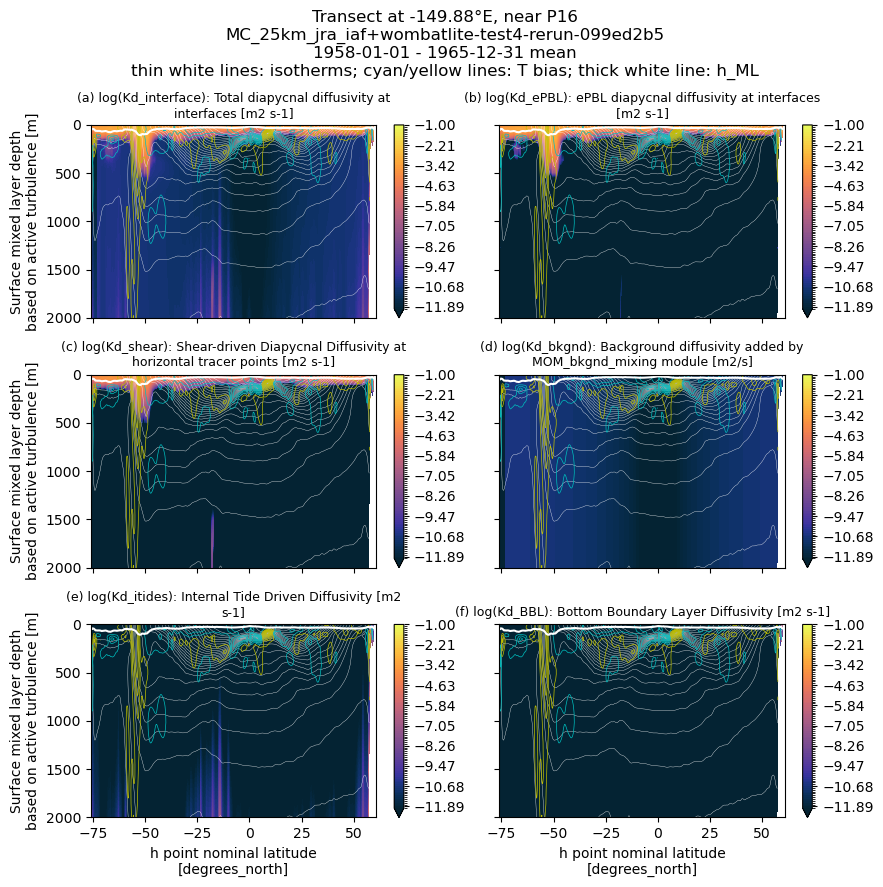

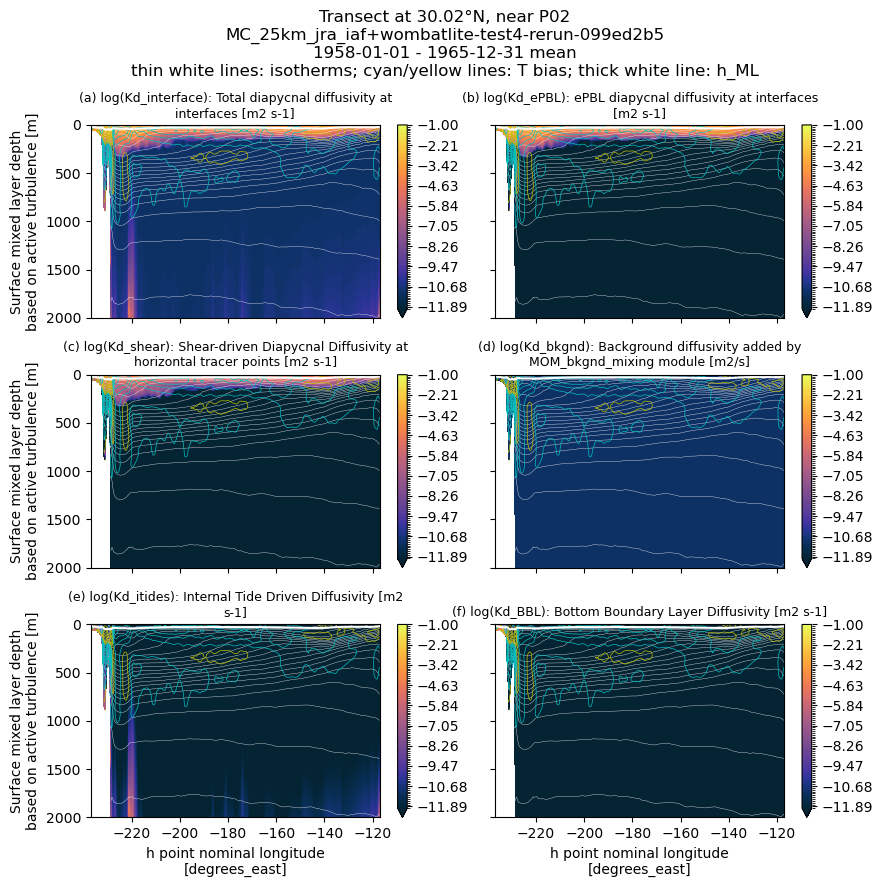

In [27]:
# %%time
expt = om3exptname
ds = om3data[expt]
ds_i = om3data_i[expt]
cmap = cmocean.cm.thermal
clevels_temp = np.arange(10., 30., 1.)
ylim = [0, 2000] #[0, None]
for transect, (minx, maxx, miny, maxy) in transects.items():
    xsel = minx if minx == maxx else slice(minx, maxx)
    ysel = miny if miny == maxy else slice(miny, maxy)
    xmethod = "nearest" if minx == maxx else None
    ymethod = "nearest" if miny == maxy else None
    woa23variable = "ptemp"  # potential temperature
    om3variable = "thetao"  # potential temperature

    npanels = len(om3varnames_i)
    ncols = 2
    nrows = (npanels+1)//ncols
    fig, axs = plt.subplots(nrows, ncols,
                            figsize=(9, 3*nrows),
                            sharex=True, sharey=True)
    fig.suptitle(f'Transect at {f"{minx:.2f}°E" if minx == maxx else f"{miny:.2f}°N"}, near {transect}\n{expt}\n{timerange.start.strftime("%Y-%m-%d")} - {timerange.stop.strftime("%Y-%m-%d")} mean\nthin white lines: isotherms; cyan/yellow lines: T bias; thick white line: h_ML', y=0.98)

    om3temp = {
        expt: ds[om3variable].sel(xh=xsel, method=xmethod).sel(yh=ysel, method=ymethod).load()
        for expt, ds in om3data.items()
    }
    om3bias = {
        expt: (ds[om3variable] - obsdata['woa23'][woa23variable]).sel(xh=xsel, method=xmethod).sel(yh=ysel, method=ymethod).load()
        for expt, ds in om3data.items()
    }
    
    # for i, om3variable in enumerate(om3varnames_i+['Kd_residual'], start=1):
    for i, om3variable in enumerate(om3varnames_i, start=1):
        try:
            om3transect = ds_i[om3variable].sel(xh=xsel, method=xmethod).sel(yh=ysel, method=ymethod).load()
        except KeyError:
            continue

        lim = 0.05
    
        plt.subplot(nrows, ncols, i)
        # plt.subplot(nrows, ncols, i).set_facecolor('gray')  # gray land
        # p1 = np.log(om3transect.where(om3transect > 1e-30, 1e-30)).plot.contourf(
        # p1 = np.log(om3transect).plot.contourf(
        p1 = np.log(np.maximum(1e-30, om3transect)).plot.contourf(
            levels=101, vmin = -12, vmax = -1, #vmin=0, vmax=lim, 
            cmap=cmap, add_colorbar=False,
        )
        om3temp[expt].plot.contour(
            levels=np.arange(0., 30., 1.),  #25, #vmin=-tlim, vmax=tlim, 
            add_colorbar=False, colors=["w"], 
            linewidths=[0.25], linestyles=["-"]
        )
        om3bias[expt].plot.contour(
            levels=np.arange(0.25, 30., 0.5),
            add_colorbar=False, colors=["y"], 
            linewidths=[0.5], linestyles=["-"]
        )
        om3bias[expt].plot.contour(
            levels=np.arange(-0.25, -30., -0.5),
            add_colorbar=False, colors=["c"], 
            linewidths=[0.5], linestyles=["-"]
        )
        om3data_2d[expt]['h_ML'].sel(xh=xsel, method=xmethod).sel(yh=ysel, method=ymethod).plot(color="w")
        # om3data_2d[expt]['ePBL_h_ML'].sel(xh=xsel, method=xmethod).sel(yh=ysel, method=ymethod).plot(color="r")
        plt.gca().set_ylim(ylim)
        plt.gca().invert_yaxis()
        plt.title("\n".join(wrap(f"({chr(ord('a')+i-1)}) log({om3variable}): {om3data_i[expt][om3variable].attrs['long_name']} [{om3data_i[expt][om3variable].attrs['units']}]", 60)), fontsize=9)
        # plt.xlabel('')
        # plt.ylabel('Depth (m)')
        plt.colorbar(p1)
        # break

    for ax in fig.get_axes():
        ax.label_outer()
    plt.tight_layout()

    mkmd.savefig(fig, f"{transect} vertical mixing transects", f"{transect} vertical mixing")
    # break

## Calculate residual - UNFINISHED!

Note: we use EPBL_IS_ADDITIVE = False        !   [Boolean] default = True
                                ! If true, the diffusivity from ePBL is added to all other diffusivities.
                                ! Otherwise, the larger of kappa-shear and ePBL diffusivities are used.


## Determine largest mixing term

Note: may miss the actual largest term if it's not in the `terms` list!

In [28]:
terms = ['Kd_BBL', 'Kd_itides', 'Kd_bkgnd', 'Kd_shear', 'Kd_ePBL']
Kd_max = om3data_i[om3exptname][terms].to_array("variable").idxmax("variable")

In [29]:
Kd_max_num = xr.where(Kd_max==terms[0], 0.,
             xr.where(Kd_max==terms[1], 1., 
             xr.where(Kd_max==terms[2], 2., 
             xr.where(Kd_max==terms[3], 3., 
             xr.where(Kd_max==terms[4], 4., Kd_max))))).astype('float')

### Plot maps of largest term at various depths

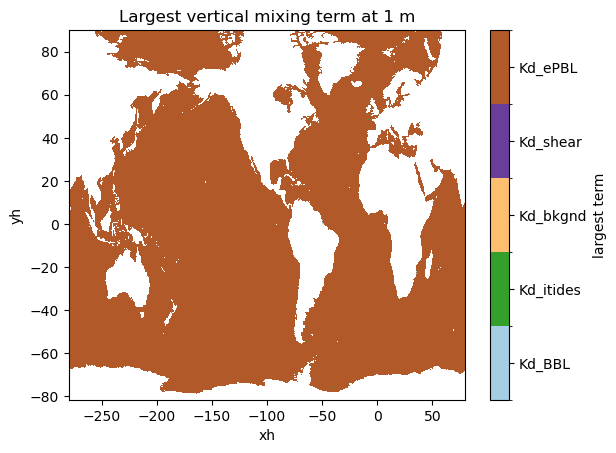

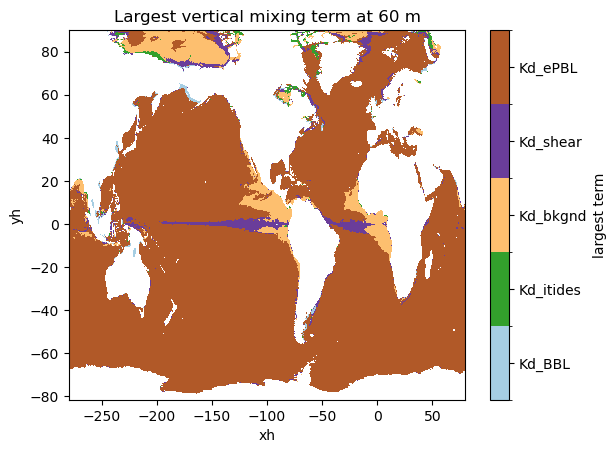

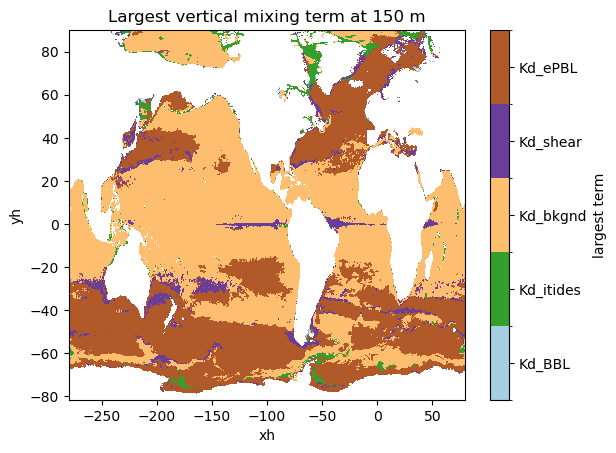

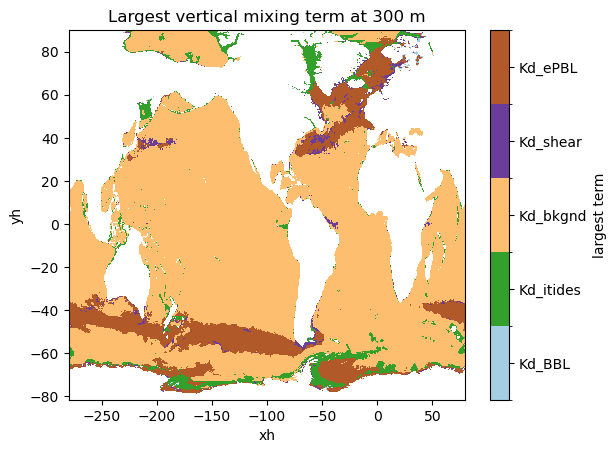

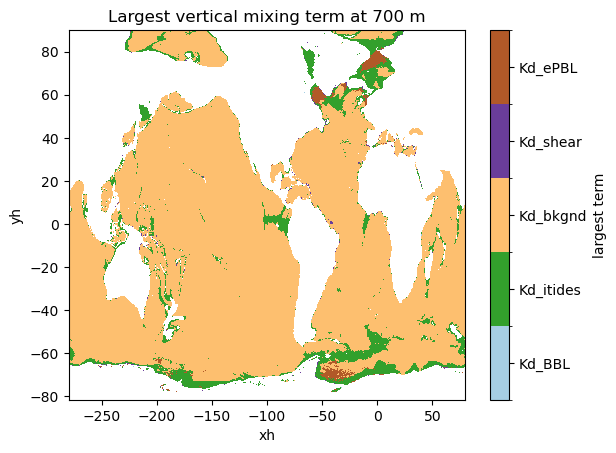

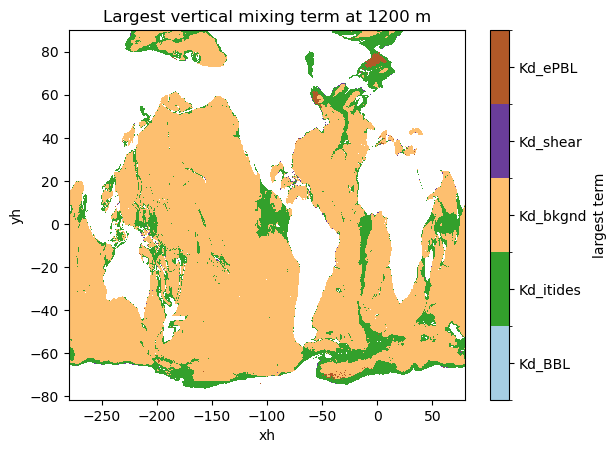

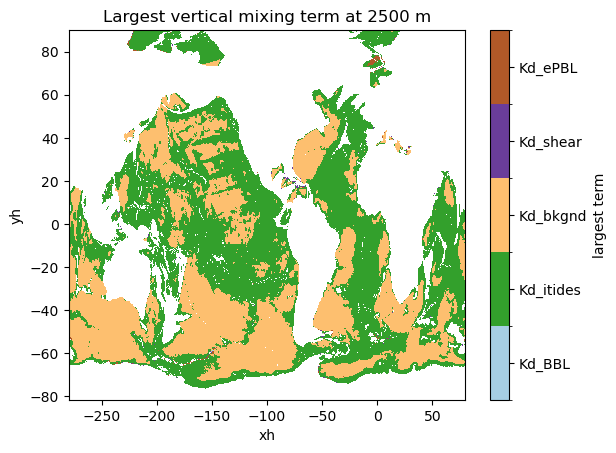

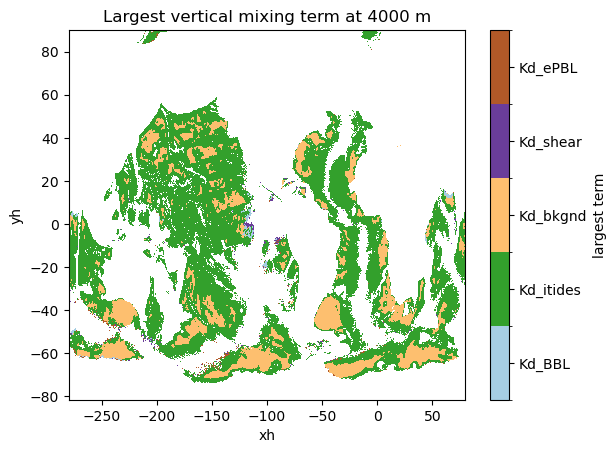

In [50]:
for d in [1, 60, 150, 300, 700, 1200, 2500, 4000]:
    plt.figure()
    Kd_max_num.sel(zi=d, method='nearest').plot(
        cmap=mpl.colormaps['Paired'],
        levels=[l-0.5 for l in range(len(terms)+1)],
        cbar_kwargs={
            'ticks': range(len(terms)),
            'format': mticker.FixedFormatter(terms),
            'label': 'largest term'})
    plt.title(f"Largest vertical mixing term at {d} m")

### Plot transects of largest term

CPU times: user 1min 10s, sys: 24 s, total: 1min 34s
Wall time: 1min 7s


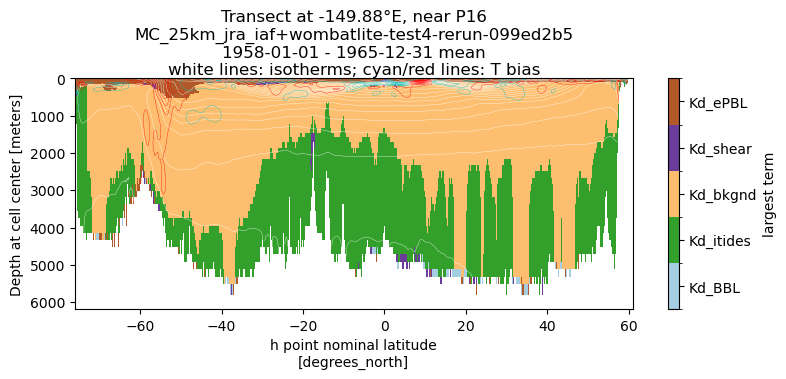

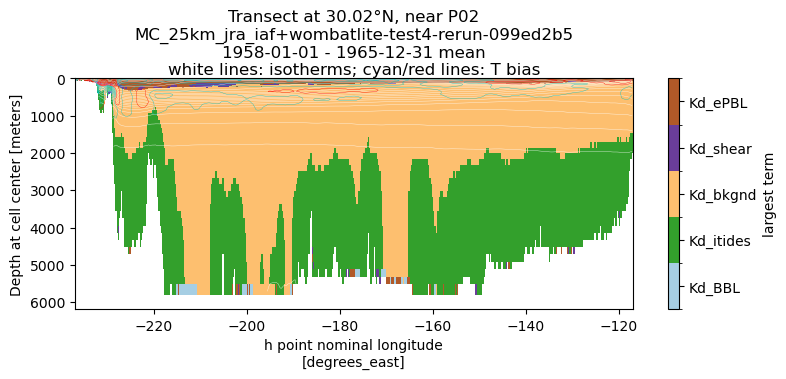

In [48]:
%%time
expt = om3exptname
ds = om3data_i[expt]
cmap = cmocean.cm.thermal
for transect, (minx, maxx, miny, maxy) in transects.items():
    xsel = minx if minx == maxx else slice(minx, maxx)
    ysel = miny if miny == maxy else slice(miny, maxy)
    xmethod = "nearest" if minx == maxx else None
    ymethod = "nearest" if miny == maxy else None
    woa23variable = "ptemp"  # potential temperature
    om3variable = "thetao"  # potential temperature

    npanels = 1
    ncols = 1
    nrows = 1
    fig = plt.subplots(nrows, ncols,
                            figsize=(9, 3*nrows),
                            sharex=True, sharey=True)

    om3temp = {
        expt: ds[om3variable].sel(xh=xsel, method=xmethod).sel(yh=ysel, method=ymethod).load()
        for expt, ds in om3data.items()
    }
    om3bias = {
        expt: (ds[om3variable] - obsdata['woa23'][woa23variable]).sel(xh=xsel, method=xmethod).sel(yh=ysel, method=ymethod).load()
        for expt, ds in om3data.items()
    }

# plt.subplot(nrows, ncols, 1).set_facecolor('gray')  # gray land
    Kd_max_num.sel(xh=xsel, method=xmethod).sel(yh=ysel, method=ymethod).plot(
        cmap=mpl.colormaps['Paired'],
        levels=[l-0.5 for l in range(len(terms)+1)],
        cbar_kwargs={
            'ticks': range(len(terms)),
            'format': mticker.FixedFormatter(terms),
            'label': 'largest term'})
    om3temp[expt].plot.contour(
        levels=np.arange(0., 30., 1.),  #25, #vmin=-tlim, vmax=tlim, 
        add_colorbar=False, colors=["w"], 
        linewidths=[0.25], linestyles=["-"]
    )
    om3bias[expt].plot.contour(
        levels=np.arange(0.25, 30., 0.5),
        add_colorbar=False, colors=["r"], 
        linewidths=[0.25], linestyles=["-"]
    )
    om3bias[expt].plot.contour(
        levels=np.arange(-0.25, -30., -0.5),
        add_colorbar=False, colors=["c"], 
        linewidths=[0.25], linestyles=["-"]
    )
    # om3data_2d[expt]['h_ML'].sel(xh=xsel, method=xmethod).sel(yh=ysel, method=ymethod).plot(color="w")
    # om3data_2d[expt]['ePBL_h_ML'].sel(xh=xsel, method=xmethod).sel(yh=ysel, method=ymethod).plot(color="r")
    plt.gca().set_ylim([0, None])
    plt.gca().invert_yaxis()
    plt.title(f'Transect at {f"{minx:.2f}°E" if minx == maxx else f"{miny:.2f}°N"}, near {transect}\n{expt}\n{timerange.start.strftime("%Y-%m-%d")} - {timerange.stop.strftime("%Y-%m-%d")} mean\nwhite lines: isotherms; cyan/red lines: T bias', y=0.98)

    mkmd.savefig(fig, f"{transect} transect of largest vertical mixing term", f"{transect} transect of largest vertical mixing term")
    # break

## Work by internal tidal mixing parameterisation

In [32]:
depth = om3datastores[expt].search(variable='deptho').to_dask()['deptho']

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/intake_esm/source.py:314: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only first dataset. Request valid dimension coordinate to silence this warning.
  warnings.warn(


In [33]:
%%time
Kd_Itidal_Work_int_z = om3data[om3exptname]['Kd_Itidal_Work'].sum('z_l').load()

CPU times: user 726 ms, sys: 550 ms, total: 1.28 s
Wall time: 741 ms


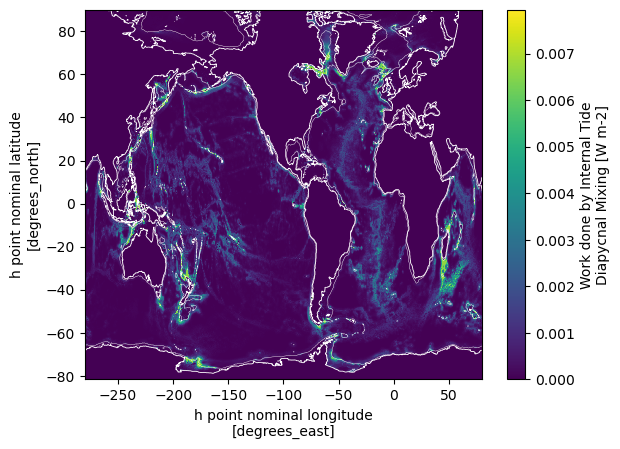

In [34]:
shelfedge = 1000
plt.figure()
Kd_Itidal_Work_int_z.plot()
plt.title(f'Depth-integrated {om3data[om3exptname]['Kd_Itidal_Work'].attrs['long_name']}\n{om3exptname}\n{timerange.start.strftime("%Y-%m-%d")} - {timerange.stop.strftime("%Y-%m-%d")} mean')
depth.fillna(0.).plot.contour(levels=[0, shelfedge],
        colors="w",
        linewidths=[0.6, 0.3],
)

In [35]:
Kd_Itidal_Work = {
            expt: om3datastores[om3exptname].search(variable='Kd_Itidal_Work').to_dask(
                xarray_open_kwargs = dict(
                    chunks=om3chunks,
                    decode_timedelta=True
                )
            )['Kd_Itidal_Work'].convert_calendar("proleptic_gregorian", use_cftime=True)
            for expt, ds in om3datastores.items()
          }

In [36]:
for expt, ds in Kd_Itidal_Work.items():
    Kd_Itidal_Work[expt] = ds.sel(time=timerange)

In [37]:
%%time
Kd_Itidal_Work_total = grid.integrate(Kd_Itidal_Work[om3exptname].sum('z_l'), ['X', 'Y']).load()

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 12.74 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


CPU times: user 9.15 s, sys: 6.76 s, total: 15.9 s
Wall time: 18.6 s


Text(0, 0.5, 'Total work [TW]')

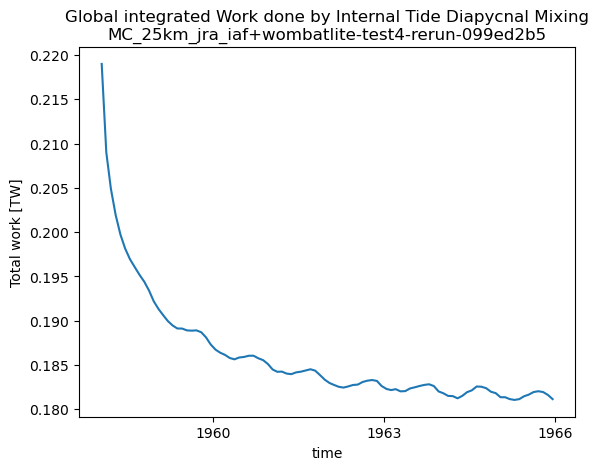

In [38]:
(Kd_Itidal_Work_total/1e12).plot()
plt.title(f"Global integrated {Kd_Itidal_Work[om3exptname].attrs['long_name']}\n{om3exptname}")
plt.ylabel("Total work [TW]")

In [39]:
%%time
Kd_Itidal_Work_total_shelf = grid.integrate(Kd_Itidal_Work[om3exptname].sum('z_l').where(depth < shelfedge), ['X', 'Y']).load()

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 12.75 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


CPU times: user 8.71 s, sys: 6.51 s, total: 15.2 s
Wall time: 18.1 s


Text(0, 0.5, 'Total work [TW]')

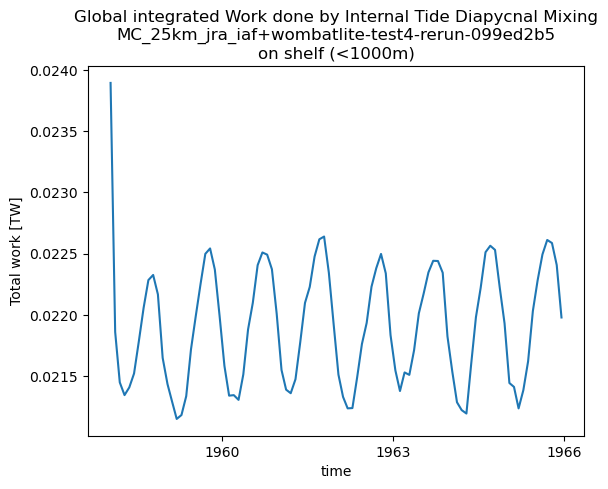

In [40]:
(Kd_Itidal_Work_total_shelf/1e12).plot()
plt.title(f"Global integrated {Kd_Itidal_Work[om3exptname].attrs['long_name']}\n{om3exptname}\non shelf (<{shelfedge}m)")
plt.ylabel("Total work [TW]")

In [41]:
%%time
Kd_Itidal_Work_hovmoller = grid.integrate(Kd_Itidal_Work[om3exptname], ['X', 'Y']).load()

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 12.72 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


CPU times: user 10 s, sys: 7.13 s, total: 17.1 s
Wall time: 22.1 s


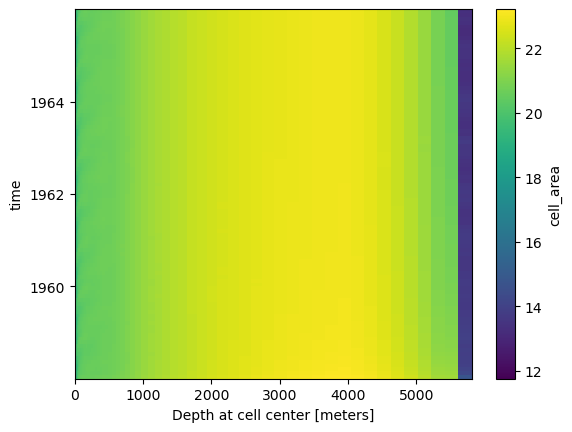

In [42]:
np.log(Kd_Itidal_Work_hovmoller).plot()

In [43]:
client.close()